<a href="https://colab.research.google.com/github/maniangdieng/LLM_IMAGERIE_MEDICAL/blob/main/MedGemma_BioMedCLIP_Ziguinchor_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MedGemma + BioMedCLIP — Assistant Radiologie
## Hôpital de la Paix de Ziguinchor

---
### AVANT DE COMMENCER
1. Activer le GPU : **Runtime > Changer le type d'exécution > T4 GPU**
2. Exécuter les cellules **dans l'ordre** : 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10
3. Ne jamais sauter une cellule
---


In [1]:
# CELLULE UNIQUE — exécuter seule, puis redémarrer
import subprocess
subprocess.run(["pip", "install", "numpy==1.26.4",
                "--force-reinstall", "--quiet"], check=True)
print("numpy 1.26.4 installé — REDÉMARRE LE KERNEL MAINTENANT")

numpy 1.26.4 installé — REDÉMARRE LE KERNEL MAINTENANT


In [2]:
# ================================================================
# BLOC 1 — INSTALLATIONS (version définitive)
# ================================================================

# ── ÉTAPE 1 : numpy en premier, avant tout autre import ──
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "numpy==1.26.4", "--force-reinstall", "--quiet"
], check=True)

# ── ÉTAPE 2 : vérification immédiate ──
import importlib
import numpy as np
importlib.reload(np)
print(f"numpy version : {np.__version__}")   # doit être 1.26.4

# ── ÉTAPE 3 : reste des dépendances ──
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "transformers>=4.50.0", "accelerate",
    "huggingface_hub", "pillow",
    "gradio==3.50.2", "fpdf2", "nibabel",
    "--quiet"
], check=True)

print("BLOC 1 OK — Toutes les dépendances installées")

/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


numpy version : 1.26.4
BLOC 1 OK — Toutes les dépendances installées


In [3]:
# ================================================================
# BLOC 2 — AUTHENTIFICATION HUGGING FACE
# ================================================================
# Prérequis : ajouter HF_TOKEN dans Secrets Colab
# (icône clé à gauche > Ajouter un secret > nom: HF_TOKEN)

from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=False)

print("BLOC 2 OK — Authentifie sur Hugging Face")


BLOC 2 OK — Authentifie sur Hugging Face


In [4]:
# ================================================================
# BLOC 3 — LIBERATION MEMOIRE GPU
# ================================================================
# Exécuter si tu relances après une erreur mémoire (OOM)
# Sinon tu peux sauter ce bloc

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch, gc

for var in ['medgemma_model', 'medgemma_processor',
            'biomedclip_model', 'biomedclip_processor']:
    try:
        del globals()[var]
    except:
        pass

gc.collect()
torch.cuda.empty_cache()

vram_libre = (torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_reserved(0))
print(f"BLOC 3 OK — VRAM disponible : {vram_libre/1e9:.1f} GB")


BLOC 3 OK — VRAM disponible : 15.6 GB


In [5]:
# ================================================================
# BLOC 4 — CHARGEMENT DU MODELE DE DETECTION VISUELLE
# ================================================================

# ================================================================

import torch
from transformers import CLIPProcessor, CLIPModel

CLIP_ID = "openai/clip-vit-large-patch14"
print("Chargement du modèle de détection visuelle...")

biomedclip_processor = CLIPProcessor.from_pretrained(CLIP_ID)
biomedclip_model     = CLIPModel.from_pretrained(
    CLIP_ID,
    dtype=torch.float32
).to("cuda").eval()

print(f"BLOC 4 OK — modèle chargé sur {next(biomedclip_model.parameters()).device}")
print(f"VRAM : {torch.cuda.memory_reserved(0)/1e9:.1f} GB")

Chargement du modèle de détection visuelle...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLOC 4 OK — modèle chargé sur cuda:0
VRAM : 1.7 GB


In [6]:
# ================================================================
# BLOC 5 — CHARGEMENT MEDGEMMA 4B
# ================================================================
# Chargé en bfloat16 — sans quantification 4-bit
# (évite les erreurs bitsandbytes sur certaines sessions Colab)
# Durée : 3-5 min (cache HuggingFace après 1er téléchargement)

from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = 'google/medgemma-4b-it'
print('Chargement MedGemma 4B-IT...')

medgemma_processor = AutoProcessor.from_pretrained(
    MODEL_ID, token=HF_TOKEN
)
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    torch_dtype=torch.bfloat16,
    device_map='auto'
)
medgemma_model.eval()

print(f"BLOC 5 OK — MedGemma charge")
print(f"VRAM totale : {torch.cuda.memory_reserved(0)/1e9:.1f} GB")


Chargement MedGemma 4B-IT...


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

BLOC 5 OK — MedGemma charge
VRAM totale : 10.3 GB


In [7]:
# ================================================================
# BLOC 6 — DETECTION BIOMEDCLIP (seuil élevé + filtrage contextuel)
# ================================================================

from PIL import Image

# Findings regroupés par région anatomique
FINDINGS_CERVEAU = [
    "brain tumor", "brain hemorrhage", "brain edema",
    "hydrocephalus", "cerebral infarction", "midline shift",
    "subdural hematoma",
]
FINDINGS_THORAX = [
    "pleural effusion", "pneumothorax", "cardiomegaly",
    "pulmonary edema", "consolidation", "atelectasis",
    "pneumonia", "lung mass", "lung nodule",
]
FINDINGS_OS = [
    "bone fracture", "rib fracture", "spinal fracture",
    "bone tumor", "joint dislocation",
]
FINDINGS_ABDOMEN = [
    "liver mass", "kidney stone", "abdominal free fluid",
    "spleen enlargement", "bowel obstruction",
]

# Tous les findings combinés
FINDINGS_TOUS = (
    FINDINGS_CERVEAU
    + FINDINGS_THORAX
    + FINDINGS_OS
    + FINDINGS_ABDOMEN
)

# Seuil élevé — réduit les faux positifs
SEUIL_DETECTION = 0.25

def detecter_avec_biomedclip(image: Image.Image, seuil: float = SEUIL_DETECTION):
    """
    Détection CLIP avec seuil élevé.
    Retourne seulement les findings vraiment saillants.
    """
    textes = [f"a medical image showing {f}" for f in FINDINGS_TOUS]

    with torch.no_grad():
        inputs = biomedclip_processor(
            text=textes,
            images=image,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to("cuda")

        outputs = biomedclip_model(**inputs)
        # Softmax (pas sigmoid) → scores relatifs, réduit les faux positifs
        logits = outputs.logits_per_image[0]
        probs  = torch.softmax(logits, dim=0).cpu().float()

    # Garder uniquement les findings avec score > seuil
    # ET limiter à 5 max (les plus probables)
    findings_scores = [
        (FINDINGS_TOUS[i], probs[i].item())
        for i in range(len(FINDINGS_TOUS))
        if probs[i].item() > seuil
    ]
    findings_scores.sort(key=lambda x: x[1], reverse=True)
    findings_detectes = [f for f, _ in findings_scores[:5]]

    statut = "Anomalies detectees" if findings_detectes else "Normal"

    # Log interne uniquement (pas affiché dans le rapport)
    print(f"[CLIP] {statut} ({len(findings_detectes)} findings retenus)")
    for f, s in findings_scores[:5]:
        print(f"  {s*100:.1f}% — {f}")

    return {
        "statut"     : statut,
        "findings"   : findings_detectes,
        "nb_findings": len(findings_detectes),
        "scores"     : probs.tolist()
    }

print("BLOC 6 OK ✅")

BLOC 6 OK ✅


In [8]:
# ================================================================
# BLOC 7 — GENERATION RAPPORT MEDGEMMA (sans entête BioMedCLIP)
# ================================================================

def generer_rapport_medgemma(image, detection_results, prompt_custom=None):
    """
    Génère un rapport radiologique propre.
    BioMedCLIP guide MedGemma en interne — pas affiché dans la sortie.
    """
    findings   = detection_results.get("findings", [])
    statut     = detection_results.get("statut", "indetermine")
    nb_finding = len(findings)

    # BioMedCLIP sert uniquement de contexte interne pour MedGemma
    if findings:
        ctx_biomedclip = (
            f"Indices détectés automatiquement (à confirmer) : "
            f"{', '.join(findings[:5])}"
        )
    else:
        ctx_biomedclip = "Aucune anomalie évidente détectée automatiquement."

    if prompt_custom and prompt_custom.strip():
        instruction = (
            f"Le médecin demande : \"{prompt_custom.strip()}\"\n\n"
            "Réponds directement à cette question en analysant l'image, "
            "puis donne les sections pertinentes du compte rendu."
        )
    else:
        instruction = (
            "Génère un compte rendu radiologique complet avec ces sections :\n"
            "**TYPE D'EXAMEN**\n"
            "**QUALITÉ TECHNIQUE**\n"
            "**STRUCTURES ANATOMIQUES**\n"
            "**OBSERVATIONS**\n"
            "**ANOMALIES DÉTECTÉES**\n"
            "**IMPRESSION DIAGNOSTIQUE**\n"
            "**RECOMMANDATIONS**"
        )

    # BioMedCLIP en contexte caché — jamais dans la sortie finale
    system_txt = (
        f"Tu es radiologue expert à l'Hôpital de la Paix de Ziguinchor, Sénégal.\n"
        f"Tu analyses des images médicales et rédiges des comptes rendus en français.\n"
        f"Ce rapport est une aide à la décision — diagnostic final = radiologue.\n\n"
        f"Contexte automatique (à valider) : {ctx_biomedclip}\n\n"
        f"{instruction}"
    )

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text" : system_txt}
        ]
    }]

    inputs = medgemma_processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(medgemma_model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = medgemma_model.generate(
            **inputs,
            max_new_tokens=500,
            do_sample=False,
            repetition_penalty=1.1,
        )

    rapport = medgemma_processor.decode(
        outputs[0][input_len:],
        skip_special_tokens=True
    )

    del inputs, outputs
    torch.cuda.empty_cache()

    # Retourne UNIQUEMENT le rapport MedGemma — propre
    return rapport.strip()

print("BLOC 7 OK ✅")

BLOC 7 OK ✅


In [9]:
# ================================================================
# BLOC 8 — PIPELINE BATCH
# ================================================================

from PIL import Image as PILImage
import os
from datetime import datetime
import gradio as gr

def redimensionner(image, taille=512):
    """Réduit l'image pour économiser la mémoire GPU"""
    img = image.copy()
    img.thumbnail((taille, taille), PILImage.LANCZOS)
    return img


# ── BioMedCLIP batch ──────────────────────────────────────────
def detecter_batch_biomedclip(liste_images, seuil=0.08):
    """
    Traite toutes les images en batch (une seule inférence GPU).
    Retourne une liste de dicts {statut, findings, nb_findings, scores}.
    """
    resultats = []
    BATCH_SIZE = 4

    for i in range(0, len(liste_images), BATCH_SIZE):
        batch = [redimensionner(img, 336) for img in liste_images[i:i+BATCH_SIZE]]
        textes = [f"a medical image showing {f}" for f in FINDINGS]

        with torch.no_grad():
            inputs = biomedclip_processor(
                text=textes,
                images=batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            ).to('cuda')
            outputs = biomedclip_model(**inputs)
            # logits_per_image : [batch_size, nb_findings]
            probs_batch = torch.sigmoid(
                outputs.logits_per_image
            ).cpu().float()

        for probs in probs_batch:
            findings = [
                FINDINGS[j]
                for j, s in enumerate(probs)
                if s.item() > seuil and "normal" not in FINDINGS[j]
            ]
            statut = "Anomalies detectees" if findings else "Normal"
            resultats.append({
                "statut"     : statut,
                "findings"   : findings,
                "nb_findings": len(findings),
                "scores"     : probs.tolist()
            })

    return resultats


# ── MedGemma batch (rapport court) ────────────────────────────
def generer_rapport_batch(image, detection, prompt_custom=None,
                           mode_rapide=True):
    """
    Rapport MedGemma optimisé pour le batch.
    mode_rapide=True → 200 tokens (4x plus rapide)
    """
    findings   = detection.get("findings", [])
    statut     = detection.get("statut", "indetermine")
    nb_finding = len(findings)

    # Image normale sans prompt → rapport court direct (pas de MedGemma)
    if statut == "Normal" and not prompt_custom:
        return (
            "**STATUT** : Normal\n"
            "**CONCLUSION** : Aucune anomalie significative detectee. "
            "Image dans les limites normales.\n"
            "**RECOMMANDATION** : Correlation clinique recommandee."
        )

    findings_texte = (
        "\n".join([f"  - {f}" for f in findings[:5]])
        if findings else "  - Aucun finding au-dessus du seuil"
    )

    if prompt_custom and prompt_custom.strip():
        instruction = f"Reponds a : \"{prompt_custom.strip()}\" en 3-4 lignes."
    elif mode_rapide:
        instruction = (
            "Genere un compte rendu COURT (5-7 lignes) avec :\n"
            "**STATUT** / **ANOMALIES** / **CONCLUSION**"
        )
    else:
        instruction = (
            "Genere un compte rendu complet avec :\n"
            "**TYPE D'EXAMEN** / **OBSERVATIONS** / "
            "**ANOMALIES** / **CONCLUSION** / **RECOMMANDATIONS**"
        )

    system_txt = (
        f"Tu es radiologue a Ziguinchor. Reponds en francais. Sois concis.\n"
        f"BioMedCLIP : {statut} ({nb_finding} findings)\n"
        f"{findings_texte}\n\n{instruction}"
    )

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": redimensionner(image, 336)},
            {"type": "text",  "text" : system_txt}
        ]
    }]

    inputs = medgemma_processor.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt"
    ).to(medgemma_model.device)

    input_len = inputs["input_ids"].shape[-1]
    max_tok   = 200 if mode_rapide else 450

    with torch.inference_mode():
        outputs = medgemma_model.generate(
            **inputs,
            max_new_tokens=max_tok,
            do_sample=False,
            repetition_penalty=1.1,
        )

    rapport = medgemma_processor.decode(
        outputs[0][input_len:], skip_special_tokens=True
    )

    del inputs, outputs
    torch.cuda.empty_cache()
    return rapport.strip()


# ── Pipeline principal (1 image) ──────────────────────────────
def analyser_pipeline_complet(image, seuil=0.08, prompt_custom=None):
    """Pipeline simple pour 1 image — utilisé dans les tests"""
    image     = redimensionner(image, 512)
    detection = detecter_batch_biomedclip([image], seuil=seuil)[0]
    rapport   = generer_rapport_medgemma(image, detection,
                                          prompt_custom=prompt_custom)
    return rapport

print("BLOC 8 OK — Pipelines definis")


BLOC 8 OK — Pipelines definis


In [10]:
# ================================================================
# BLOC 9 — SUPPORT NIFTI + PDF
# ================================================================

import nibabel as nib
import numpy as np
from fpdf import FPDF
from datetime import datetime
import tempfile, os


# ── NIfTI → PIL ───────────────────────────────────────────────
def nifti_vers_coupes(chemin_fichier, nb_coupes_max=10):
    """
    Convertit un .nii ou .nii.gz en liste de (PIL Image, nom_coupe).
    Extrait les coupes les plus informatives (milieu du volume 3D).
    """
    img_nib = nib.load(chemin_fichier)
    data    = img_nib.get_fdata()

    vmin, vmax = data.min(), data.max()
    if vmax - vmin > 0:
        data = (data - vmin) / (vmax - vmin) * 255
    else:
        data = np.zeros_like(data)
    data = data.astype(np.uint8)

    coupes = []

    if data.ndim == 3:
        _, _, nb_z = data.shape
        debut = int(nb_z * 0.2)
        fin   = int(nb_z * 0.8)
        pas   = max(1, (fin - debut) // nb_coupes_max)
        for idx in list(range(debut, fin, pas))[:nb_coupes_max]:
            img = PILImage.fromarray(data[:, :, idx]).convert("RGB")
            img.thumbnail((512, 512), PILImage.LANCZOS)
            coupes.append((img, f"coupe_{idx:03d}"))

    elif data.ndim == 4:
        _, _, nb_z, nb_vol = data.shape
        vol_mid = nb_vol // 2
        z_mid   = nb_z   // 2
        for idx in range(max(0, z_mid - 2), min(nb_z, z_mid + 3)):
            img = PILImage.fromarray(data[:, :, idx, vol_mid]).convert("RGB")
            img.thumbnail((512, 512), PILImage.LANCZOS)
            coupes.append((img, f"vol{vol_mid:02d}_z{idx:03d}"))

    print(f"NIfTI : {len(coupes)} coupes extraites")
    return coupes


def charger_fichiers_mixtes(fichiers):
    """
    Charge tous les formats :
    - JPG / PNG  → 1 image PIL
    - .nii/.gz   → N coupes PIL extraites automatiquement
    Retourne liste de (PIL Image, nom_fichier)
    """
    resultat = []
    for chemin in fichiers:
        if not chemin:
            continue
        nom = os.path.basename(chemin)
        try:
            if nom.lower().endswith(('.jpg', '.jpeg', '.png')):
                img = PILImage.open(chemin).convert("RGB")
                img.thumbnail((512, 512), PILImage.LANCZOS)
                resultat.append((img, nom))

            elif nom.lower().endswith('.nii') or nom.lower().endswith('.nii.gz'):
                print(f"NIfTI detecte : {nom}")
                coupes = nifti_vers_coupes(chemin)
                base   = nom.replace('.nii.gz', '').replace('.nii', '')
                for img_pil, id_coupe in coupes:
                    resultat.append((img_pil, f"{base}_{id_coupe}"))
            else:
                print(f"Format ignore : {nom}")
        except Exception as e:
            print(f"Erreur chargement {nom} : {e}")
    return resultat


# ── Helpers PDF ───────────────────────────────────────────────
def _safe(texte):
    return str(texte).encode('latin-1', 'replace').decode('latin-1')

def _entete_page(pdf, titre_page, couleur=(6, 78, 59)):
    pdf.set_fill_color(*couleur)
    pdf.rect(0, 0, 210, 16, 'F')
    pdf.set_font("Helvetica", "B", 10)
    pdf.set_text_color(255, 255, 255)
    pdf.set_xy(15, 4)
    pdf.cell(0, 8, _safe(titre_page), ln=True)
    pdf.ln(6)

def _ecrire_rapport(pdf, texte, couleur_titre=(6, 78, 59)):
    for ligne in texte.split('\n'):
        ligne = _safe(ligne.strip())
        if not ligne:
            pdf.ln(2)
            continue
        if ligne.startswith('**') and ligne.endswith('**'):
            pdf.ln(3)
            pdf.set_x(15)
            pdf.set_font("Helvetica", "B", 10)
            pdf.set_text_color(*couleur_titre)
            pdf.cell(0, 6, ligne.replace('**', ''), ln=True)
            pdf.set_draw_color(209, 250, 229)
            pdf.set_line_width(0.2)
            pdf.line(15, pdf.get_y(), 195, pdf.get_y())
            pdf.ln(2)
        elif ligne.startswith('-') or ligne.startswith(chr(8226)):
            pdf.set_x(20)
            pdf.set_font("Helvetica", "", 9)
            pdf.set_text_color(55, 65, 81)
            pdf.multi_cell(170, 5, "- " + ligne.lstrip('-').lstrip(chr(8226)).strip())
        else:
            pdf.set_x(15)
            pdf.set_font("Helvetica", "", 9)
            pdf.set_text_color(30, 41, 59)
            pdf.multi_cell(180, 5, ligne)


# ── PDF simple (1 image) ──────────────────────────────────────
def generer_pdf_simple(rapport_texte, nom_patient="", partie_corps=""):
    if not rapport_texte or not rapport_texte.strip():
        return None

    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=22)
    pdf.add_page()

    pdf.set_fill_color(6, 78, 59)
    pdf.rect(0, 0, 210, 44, 'F')
    pdf.set_font("Helvetica", "B", 17)
    pdf.set_text_color(255, 255, 255)
    pdf.set_xy(15, 7)
    pdf.cell(0, 10, _safe("RAPPORT RADIOLOGIQUE — MEDGEMMA AI"), ln=True)
    pdf.set_font("Helvetica", "", 9)
    pdf.set_text_color(167, 243, 208)
    pdf.set_xy(15, 20)
    pdf.cell(0, 6, _safe("Hopital de la Paix de Ziguinchor — Service d'Imagerie"), ln=True)
    pdf.set_xy(15, 29)
    pdf.cell(0, 6, _safe(f"Genere le {datetime.now().strftime('%d/%m/%Y a %H:%M')}"), ln=True)

    if nom_patient or partie_corps:
        pdf.set_xy(130, 20)
        pdf.set_text_color(255, 255, 255)
        pdf.set_font("Helvetica", "B", 9)
        if nom_patient:
            pdf.cell(0, 6, _safe(f"Patient : {nom_patient}"), ln=True)
        pdf.set_xy(130, 29)
        if partie_corps:
            pdf.cell(0, 6, _safe(f"Region  : {partie_corps}"), ln=True)

    pdf.set_draw_color(16, 185, 129)
    pdf.set_line_width(0.8)
    pdf.line(15, 48, 195, 48)
    pdf.ln(16)

    _ecrire_rapport(pdf, rapport_texte)

    pdf.set_y(-22)
    pdf.set_draw_color(16, 185, 129)
    pdf.set_line_width(0.4)
    pdf.line(15, pdf.get_y(), 195, pdf.get_y())
    pdf.ln(3)
    pdf.set_font("Helvetica", "I", 7)
    pdf.set_text_color(130, 130, 130)
    pdf.set_x(15)
    pdf.multi_cell(180, 4, _safe(
        "AVERTISSEMENT : Rapport genere par IA (MedGemma 4B + BioMedCLIP). "
        "Aide a la decision uniquement. "
        "Diagnostic final sous responsabilite exclusive du radiologue."
    ))

    chemin = f"/tmp/rapport_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
    pdf.output(chemin)
    return chemin


# ── PDF batch (N images) ──────────────────────────────────────
def generer_pdf_batch(resultats, nom_patient="", partie_corps=""):
    if not resultats:
        return None

    nb_anomalies = sum(
        1 for r in resultats if r["statut"] not in ["Normal", "ERREUR"]
    )

    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=22)

    # Page de garde
    pdf.add_page()
    pdf.set_fill_color(6, 78, 59)
    pdf.rect(0, 0, 210, 297, 'F')
    pdf.set_font("Helvetica", "B", 28)
    pdf.set_text_color(255, 255, 255)
    pdf.set_xy(20, 70)
    pdf.cell(0, 15, _safe("RAPPORT D'IMAGERIE"), ln=True)
    pdf.set_xy(20, 88)
    pdf.cell(0, 15, _safe("MEDICALE — BATCH"), ln=True)
    pdf.set_draw_color(16, 185, 129)
    pdf.set_line_width(2)
    pdf.line(20, 113, 190, 113)

    pdf.set_font("Helvetica", "", 12)
    pdf.set_text_color(167, 243, 208)
    infos = [
        ("Patient",           nom_patient   or "Non renseigne"),
        ("Region anatomique", partie_corps  or "Non renseignee"),
        ("Images analysees",  str(len(resultats))),
        ("Anomalies",         str(nb_anomalies)),
        ("Normales",          str(len(resultats) - nb_anomalies)),
        ("Date",              datetime.now().strftime('%d/%m/%Y a %H:%M')),
    ]
    y = 122
    for label, val in infos:
        pdf.set_xy(20, y)
        pdf.set_text_color(167, 243, 208)
        pdf.cell(65, 9, _safe(f"{label} :"), ln=False)
        pdf.set_text_color(255, 255, 255)
        pdf.cell(0, 9, _safe(val), ln=True)
        y += 12

    pdf.set_font("Helvetica", "I", 10)
    pdf.set_text_color(100, 180, 140)
    pdf.set_xy(20, 265)
    pdf.cell(0, 7, _safe("Hopital de la Paix de Ziguinchor"), ln=True)
    pdf.set_xy(20, 274)
    pdf.cell(0, 7, _safe("Service d'Imagerie Medicale — MedGemma AI"), ln=True)

    # Page résumé
    pdf.add_page()
    _entete_page(pdf, "RESUME GLOBAL")

    stats = [
        ("Images analysees",    len(resultats)),
        ("Anomalies detectees", nb_anomalies),
        ("Images normales",     len(resultats) - nb_anomalies),
        ("Taux d'anomalies",    f"{nb_anomalies/max(len(resultats),1)*100:.1f}%"),
    ]
    for label, val in stats:
        pdf.set_x(15)
        pdf.set_font("Helvetica", "B", 10)
        pdf.set_text_color(6, 78, 59)
        pdf.cell(90, 8, _safe(label), border="B", ln=False)
        pdf.set_font("Helvetica", "", 10)
        pdf.set_text_color(30, 41, 59)
        pdf.cell(0, 8, _safe(str(val)), border="B", ln=True)
    pdf.ln(8)

    # Tableau récap
    pdf.set_font("Helvetica", "B", 9)
    pdf.set_fill_color(6, 78, 59)
    pdf.set_text_color(255, 255, 255)
    pdf.set_x(15)
    for col, w in [("#", 12), ("Fichier", 70), ("Statut", 40), ("Findings", 63)]:
        pdf.cell(w, 8, _safe(col), fill=True, border=1)
    pdf.ln()

    for r in resultats:
        anomalie  = r["statut"] not in ["Normal", "ERREUR"]
        couleur_t = (160, 60, 0) if anomalie else (6, 78, 59)
        if r["statut"] == "ERREUR":
            couleur_t = (180, 0, 0)

        nom_court = (r["nom"][:35] + "…") if len(r["nom"]) > 35 else r["nom"]
        findings  = ", ".join(r["findings"][:2]) if r["findings"] else "—"

        pdf.set_font("Helvetica", "", 8)
        pdf.set_text_color(*couleur_t)
        pdf.set_x(15)
        pdf.cell(12, 7, _safe(f"{r['index']:03d}"),  border=1)
        pdf.cell(70, 7, _safe(nom_court),             border=1)
        pdf.cell(40, 7, _safe(r["statut"]),           border=1)
        pdf.cell(63, 7, _safe(findings[:30]),         border=1)
        pdf.ln()

    # 1 page par image
    for r in resultats:
        pdf.add_page()
        anomalie = r["statut"] not in ["Normal", "ERREUR"]
        couleur  = (139, 0, 0) if anomalie else (6, 78, 59)
        _entete_page(
            pdf,
            f"Image {r['index']:03d} — {r['nom'][:45]} — {r['statut']}",
            couleur=couleur
        )
        _ecrire_rapport(pdf, r["rapport"], couleur_titre=couleur)

    # Footer
    pdf.set_y(-22)
    pdf.set_draw_color(16, 185, 129)
    pdf.set_line_width(0.4)
    pdf.line(15, pdf.get_y(), 195, pdf.get_y())
    pdf.ln(3)
    pdf.set_font("Helvetica", "I", 7)
    pdf.set_text_color(130, 130, 130)
    pdf.set_x(15)
    pdf.multi_cell(180, 4, _safe(
        "AVERTISSEMENT : Aide a la decision uniquement. "
        "Diagnostic final sous responsabilite exclusive du radiologue."
    ))

    chemin = f"/tmp/rapport_batch_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
    pdf.output(chemin)
    return chemin

print("BLOC 9 OK — NIfTI + PDF definis")


BLOC 9 OK — NIfTI + PDF definis


In [11]:
# ================================================================
# BLOC 10 — INTERFACE GRADIO (version finale stable)
# Design  : thème natif Gradio "soft" → textes toujours visibles
# Upload  : 1 image / plusieurs images / dossier ZIP complet
# Rapport : UN seul rapport consolidé pour tout type d'upload
# ================================================================

import gradio as gr
from PIL import Image as PILImage
from datetime import datetime
import os, re, zipfile, tempfile, shutil

# ── Nettoyage intro MedGemma ───────────────────────────────────
PREFIXES = [
    r"^Absolument\s*[!,.]?\s*",
    r"^Bien sûr\s*[!,.]?\s*",
    r"^Voici\s+.{0,120}[,:\n]",
    r"^Je vais\s+.{0,120}\.\s*",
    r"^Certainly\s*[!,.]?\s*",
    r"^D'accord\s*[!,.]?\s*",
    r"^En tant que radiologue\s*.{0,120}[,:\n]",
    r"^Basé sur .{0,120}[,:\n]",
    r"^Sur la base .{0,120}[,:\n]",
]
def nettoyer(texte):
    t = texte.strip()
    for p in PREFIXES:
        t = re.sub(p, "", t, flags=re.IGNORECASE|re.DOTALL).lstrip()
    while t.startswith("\n"):
        t = t[1:]
    return t.strip()


# ── Chargement images ──────────────────────────────────────────
def charger_depuis_fichiers(fichiers):
    """Charge une liste de fichiers uploadés (f.name = chemin)."""
    res = []
    for f in (fichiers or []):
        nom = os.path.basename(f.name)
        try:
            if nom.lower().endswith(('.jpg','.jpeg','.png')):
                img = PILImage.open(f.name).convert("RGB")
                img.thumbnail((512,512), PILImage.LANCZOS)
                res.append((img, nom))
            elif nom.lower().endswith(('.nii','.nii.gz')):
                for img_pil, id_c in nifti_vers_coupes(f.name):
                    base = nom.replace('.nii.gz','').replace('.nii','')
                    res.append((img_pil, f"{base}_{id_c}"))
        except Exception as e:
            print(f"Erreur {nom}: {e}")
    return res

def charger_depuis_zip(f_zip):
    """Extrait un ZIP et charge toutes les images qu'il contient."""
    if not f_zip:
        return [], None
    tmpdir = tempfile.mkdtemp(prefix="medgemma_")
    try:
        with zipfile.ZipFile(f_zip.name, 'r') as z:
            z.extractall(tmpdir)
    except Exception as e:
        print(f"Erreur ZIP: {e}")
        return [], tmpdir

    chemins = []
    for racine, _, flist in os.walk(tmpdir):
        for fname in sorted(flist):
            if fname.lower().endswith(('.jpg','.jpeg','.png','.nii','.nii.gz')):
                chemins.append((os.path.join(racine, fname), fname))
    chemins.sort(key=lambda x: x[1])
    print(f"ZIP: {len(chemins)} fichiers trouvés")

    res = []
    for chemin, nom in chemins:
        try:
            if nom.lower().endswith(('.jpg','.jpeg','.png')):
                img = PILImage.open(chemin).convert("RGB")
                img.thumbnail((512,512), PILImage.LANCZOS)
                res.append((img, nom))
            elif nom.lower().endswith(('.nii','.nii.gz')):
                for img_pil, id_c in nifti_vers_coupes(chemin):
                    base = nom.replace('.nii.gz','').replace('.nii','')
                    res.append((img_pil, f"{base}_{id_c}"))
        except Exception as e:
            print(f"Erreur {nom}: {e}")
    return res, tmpdir


# ── Rapport consolidé (un seul pour N images) ─────────────────
def generer_rapport_consolide(resultats, nom_patient, partie_corps):
    """
    Génère UN seul PDF consolidé pour toutes les images analysées.
    Structure : page de garde → résumé global → tableau → détail anomalies.
    """
    nb           = len(resultats)
    anomalies    = [r for r in resultats if r["statut"] != "Normal"]
    nb_anomalies = len(anomalies)
    nb_normales  = nb - nb_anomalies

    # ── Texte résumé pour l'interface ─────────────────────────
    resume = (
        f"ANALYSE COMPLETE — {nb} image(s)\n"
        f"{'='*52}\n"
        f"  Patient          : {nom_patient or 'Non renseigne'}\n"
        f"  Region           : {partie_corps or 'Non renseignee'}\n"
        f"  Images analysees : {nb}\n"
        f"  Anomalies        : {nb_anomalies}\n"
        f"  Normales         : {nb_normales}\n"
        f"  Taux             : {nb_anomalies/nb*100:.0f}%\n"
        f"  Date             : {datetime.now().strftime('%d/%m/%Y %H:%M')}\n"
        f"{'='*52}\n\n"
    )

    if anomalies:
        resume += "IMAGES AVEC ANOMALIES :\n" + "─"*40 + "\n"
        for r in anomalies:
            resume += f"  [!] {r['nom'][:40]}\n"
            if r["findings"]:
                resume += f"      {', '.join(r['findings'][:3])}\n"
            if r["rapport"]:
                # Extrait les 3 premières lignes du rapport
                lignes = [l for l in r["rapport"].split("\n") if l.strip()][:3]
                for l in lignes:
                    resume += f"      {l[:70]}\n"
            resume += "\n"

    if nb_normales > 0:
        resume += f"\nIMAGES NORMALES ({nb_normales}) :\n" + "─"*40 + "\n"
        for r in resultats:
            if r["statut"] == "Normal":
                resume += f"  [OK] {r['nom'][:45]}\n"

    chemin_pdf = generer_pdf_batch(resultats, nom_patient, partie_corps)
    return resume, chemin_pdf


# ── Fonction principale ────────────────────────────────────────
def analyser(fichiers, f_zip, prompt_txt, seuil, nom_patient, partie_corps):
    tmpdir = None
    try:
        # ── Source des images ─────────────────────────────────
        if f_zip is not None:
            print("Mode ZIP...")
            images_et_noms, tmpdir = charger_depuis_zip(f_zip)
        elif fichiers:
            print("Mode fichiers...")
            images_et_noms = charger_depuis_fichiers(fichiers)
        else:
            return "Chargez des images ou un dossier ZIP.", None

        if not images_et_noms:
            return "Aucune image trouvée.", None

        nb     = len(images_et_noms)
        prompt = prompt_txt.strip() if prompt_txt.strip() else None
        print(f"{nb} image(s) à analyser")

        # ── 1 seule image → rapport simple ───────────────────
        if nb == 1:
            img, nom = images_et_noms[0]
            detection = detecter_avec_biomedclip(img, seuil=seuil)
            rapport   = generer_rapport_medgemma(img, detection,
                                                  prompt_custom=prompt)
            rapport   = nettoyer(rapport)
            chemin    = generer_pdf_simple(rapport, nom_patient, partie_corps)
            return rapport, chemin

        # ── N images → rapport consolidé ─────────────────────
        debut = datetime.now()

        # 1. CLIP sur toutes les images en batch
        print(f"BioMedCLIP batch — {nb} images...")
        imgs_seules = [img for img, _ in images_et_noms]
        detections  = detecter_batch_biomedclip(imgs_seules, seuil=seuil)
        nb_anom     = sum(1 for d in detections if d["statut"] != "Normal")
        print(f"CLIP OK — {nb_anom}/{nb} anomalie(s)")

        # 2. MedGemma — seulement sur les images anormales (optimisation)
        #    Pour les images normales : rapport court prédéfini
        resultats = []
        idx_anom  = 0
        for i, ((img, nom), det) in enumerate(zip(images_et_noms, detections)):
            if det["statut"] != "Normal":
                print(f"MedGemma {idx_anom+1}/{nb_anom} — {nom[:35]}")
                rapport = generer_rapport_batch(
                    img, det,
                    prompt_custom=prompt,
                    mode_rapide=(nb_anom > 15)
                )
                rapport = nettoyer(rapport)
                idx_anom += 1
            else:
                rapport = (
                    "Aucune anomalie significative détectée. "
                    "Image dans les limites normales. "
                    "Corrélation clinique recommandée."
                )

            resultats.append({
                "index"   : i + 1,
                "nom"     : nom,
                "statut"  : det["statut"],
                "findings": det["findings"],
                "rapport" : rapport,
            })

        duree = (datetime.now() - debut).seconds
        print(f"Terminé en {duree}s")

        resume, chemin_pdf = generer_rapport_consolide(
            resultats, nom_patient, partie_corps
        )
        resume = (
            f"[Analyse terminee en {duree//60}min {duree%60}s]\n\n"
            + resume
        )
        return resume, chemin_pdf

    finally:
        if tmpdir and os.path.exists(tmpdir):
            shutil.rmtree(tmpdir, ignore_errors=True)


# ════════════════════════════════════════════════════════════════
# INTERFACE — thème natif "soft" (aucun override CSS sur les textes)
# ════════════════════════════════════════════════════════════════
try:
    theme = gr.themes.Soft(primary_hue="green", neutral_hue="slate")
except Exception:
    theme = "soft"

with gr.Blocks(
    theme=theme,
    title="MedGemma — Hôpital de la Paix"
) as demo:

    # ── En-tête HTML pur — inline styles seulement ───────────
    gr.HTML("""
    <div style="
        background-color:#065f46;
        padding:18px 26px;
        border-radius:10px;
        margin-bottom:16px;
        display:flex;
        align-items:center;
        justify-content:space-between;
        box-sizing:border-box;
        width:100%;
    ">
        <div style="display:flex;align-items:center;gap:14px;">
            <div style="
                width:44px;height:44px;
                min-width:44px;
                background:#ffffff;
                border-radius:10px;
                display:flex;align-items:center;justify-content:center;
                font-size:22px;
            ">⚕</div>
            <div>
                <div style="font-size:17px;font-weight:700;color:#ffffff;line-height:1.25;">
                    MedGemma AI — Assistant Radiologie
                </div>
                <div style="font-size:11px;color:#6ee7b7;margin-top:3px;">
                    Hôpital de la Paix de Ziguinchor &nbsp;·&nbsp; Service d'Imagerie Médicale
                </div>
            </div>
        </div>
        <div style="
            background:rgba(255,255,255,0.15);
            border-radius:18px;padding:5px 13px;
            display:flex;align-items:center;gap:7px;
        ">
            <div style="
                width:7px;height:7px;
                border-radius:50%;background:#4ade80;
            "></div>
            <span style="font-size:11px;color:#ffffff;font-weight:500;">
                MedGemma 4B + CLIP
            </span>
        </div>
    </div>
    """)

    with gr.Row():

        # ── Colonne gauche ────────────────────────────────────
        with gr.Column(scale=1):

            gr.Markdown("#### Informations patient")
            with gr.Row():
                nom_patient  = gr.Textbox(
                    label="Nom / ID patient",
                    placeholder="Ex : Moussa Diallo",
                    scale=2
                )
                partie_corps = gr.Textbox(
                    label="Région anatomique",
                    placeholder="Ex : Crâne, Thorax",
                    scale=1
                )

            gr.Markdown("#### Upload images")
            with gr.Tab("Fichiers individuels"):
                fichiers = gr.File(
                    label="JPG · PNG · .nii · .nii.gz"
                          "  —  sélection multiple : Ctrl+clic",
                    file_count="multiple",
                    file_types=[".jpg", ".jpeg", ".png", ".nii", ".gz"],
                    type="file"
                )

            with gr.Tab("Dossier complet (ZIP)"):
                gr.Markdown(
                    "Compressez votre dossier en `.zip` "
                    "(clic droit → Compresser / Envoyer vers), "
                    "puis uploadez le fichier ici. "
                    "Toutes les images seront analysées automatiquement."
                )
                f_zip = gr.File(
                    label="Dossier de radiographies (.zip)",
                    file_count="single",
                    file_types=[".zip"],
                    type="file"
                )

            gr.Markdown("#### Question clinique")
            with gr.Row():
                for label, txt in [
                    ("Compte rendu", "Génère un compte rendu radiologique complet et structuré"),
                    ("Anomalies",    "Décris toutes les anomalies visibles avec précision"),
                    ("Fractures",    "Recherche toute fracture ou lésion osseuse"),
                    ("Poumons",      "Analyse les champs pulmonaires et le médiastin"),
                    ("Tumeurs",      "Détecte toute masse, nodule ou tumeur suspecte"),
                ]:
                    gr.Button(label, size="sm").click(
                        fn=lambda t=txt: t,
                        outputs=[]
                    )

            prompt = gr.Textbox(
                label="Question (laisser vide = compte rendu complet)",
                placeholder="Ex : Y a-t-il une tumeur cérébrale ?",
                lines=2
            )

            # Connecter les boutons prompt
            for btn_p, txt_p in [
                ("Compte rendu", "Génère un compte rendu radiologique complet et structuré"),
                ("Anomalies",    "Décris toutes les anomalies visibles avec précision"),
                ("Fractures",    "Recherche toute fracture ou lésion osseuse"),
                ("Poumons",      "Analyse les champs pulmonaires et le médiastin"),
                ("Tumeurs",      "Détecte toute masse, nodule ou tumeur suspecte"),
            ]:
                pass  # Les boutons Gradio sont plus fiables que onclick JS

            gr.HTML("""
            <div style="
                display:flex;flex-wrap:wrap;gap:6px;margin:8px 0 4px;
            ">
            <button onclick="(function(){
                var t=document.querySelector('textarea[data-testid]');
                var all=document.querySelectorAll('textarea');
                var target=null;
                for(var i=0;i<all.length;i++){
                    if(all[i].closest('.block') &&
                       all[i].placeholder.includes('laisser vide')){
                        target=all[i]; break;
                    }
                }
                if(target){
                    target.value='Génère un compte rendu complet et structuré';
                    target.dispatchEvent(new Event('input',{bubbles:true}));
                }
            })()" style="
                background:#dcfce7;border:1px solid #4ade80;
                border-radius:14px;padding:4px 12px;
                font-size:11px;font-weight:600;color:#14532d;cursor:pointer;
            ">Compte rendu</button>
            <button onclick="(function(){
                var all=document.querySelectorAll('textarea');
                for(var i=0;i<all.length;i++){
                    if(all[i].placeholder.includes('laisser vide')){
                        all[i].value='Décris toutes les anomalies visibles avec précision';
                        all[i].dispatchEvent(new Event('input',{bubbles:true}));break;
                    }
                }
            })()" style="
                background:#dcfce7;border:1px solid #4ade80;
                border-radius:14px;padding:4px 12px;
                font-size:11px;font-weight:600;color:#14532d;cursor:pointer;
            ">Anomalies</button>
            <button onclick="(function(){
                var all=document.querySelectorAll('textarea');
                for(var i=0;i<all.length;i++){
                    if(all[i].placeholder.includes('laisser vide')){
                        all[i].value='Recherche toute fracture ou lésion osseuse';
                        all[i].dispatchEvent(new Event('input',{bubbles:true}));break;
                    }
                }
            })()" style="
                background:#dcfce7;border:1px solid #4ade80;
                border-radius:14px;padding:4px 12px;
                font-size:11px;font-weight:600;color:#14532d;cursor:pointer;
            ">Fractures</button>
            <button onclick="(function(){
                var all=document.querySelectorAll('textarea');
                for(var i=0;i<all.length;i++){
                    if(all[i].placeholder.includes('laisser vide')){
                        all[i].value='Analyse les poumons et le médiastin';
                        all[i].dispatchEvent(new Event('input',{bubbles:true}));break;
                    }
                }
            })()" style="
                background:#dcfce7;border:1px solid #4ade80;
                border-radius:14px;padding:4px 12px;
                font-size:11px;font-weight:600;color:#14532d;cursor:pointer;
            ">Poumons</button>
            <button onclick="(function(){
                var all=document.querySelectorAll('textarea');
                for(var i=0;i<all.length;i++){
                    if(all[i].placeholder.includes('laisser vide')){
                        all[i].value='Détecte toute masse, nodule ou tumeur suspecte';
                        all[i].dispatchEvent(new Event('input',{bubbles:true}));break;
                    }
                }
            })()" style="
                background:#dcfce7;border:1px solid #4ade80;
                border-radius:14px;padding:4px 12px;
                font-size:11px;font-weight:600;color:#14532d;cursor:pointer;
            ">Tumeurs</button>
            </div>
            """)

            seuil = gr.Slider(
                minimum=0.10, maximum=0.40,
                value=0.25, step=0.01,
                label="Sensibilité de détection CLIP (0.25 recommandé)"
            )

            btn = gr.Button(
                "⚕  Lancer l'analyse",
                variant="primary",
                size="lg"
            )

        # ── Colonne droite ────────────────────────────────────
        with gr.Column(scale=2):

            gr.Markdown("#### Rapport d'analyse")
            out = gr.Textbox(
                label="",
                lines=32,
                max_lines=60,
                interactive=False,
                placeholder=(
                    "Le rapport consolidé apparaîtra ici.\n\n"
                    "1 image      → rapport structuré complet\n"
                    "2+ images    → résumé global + détail anomalies\n"
                    "Dossier ZIP  → analyse complète → 1 seul rapport PDF\n\n"
                    "Le PDF est téléchargeable ci-dessous dès la fin."
                )
            )

            pdf_out = gr.File(
                label="Rapport PDF consolidé — cliquer pour télécharger"
            )

    gr.HTML("""
    <div style="
        margin-top:14px;padding:11px 16px;
        background:red;
        border:1px solid #fde68a;
        border-left:4px solid #f59e0b;
        border-radius:8px;
    ">
        <p style="font-size:12px;font-weight:700;color:#92400e;margin:0 0 3px;">
            Aide à la décision médicale uniquement
        </p>
        <p style="font-size:11px;color:#92400e;margin:0;line-height:1.6;">
            Rapport généré par IA (MedGemma 4B + CLIP).
            Ne constitue pas un diagnostic certifié.
            Le diagnostic final est sous la responsabilité exclusive du médecin radiologue.
        </p>
    </div>
    """)

    btn.click(
        fn=analyser,
        inputs=[fichiers, f_zip, prompt, seuil, nom_patient, partie_corps],
        outputs=[out, pdf_out]
    )

print("Lancement...")
demo.queue()
demo.launch(share=True)

Lancement...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://c4badf8546d2fa1584.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


---
## Cellules optionnelles — Évaluation sur dataset Kaggle

In [12]:
# ================================================================
# KAGGLE A — CONFIGURATION
# ================================================================

import os

KAGGLE_USERNAME = "maniangdieng"
KAGGLE_KEY      = "KGAT_f0d687c5a555c9d3bd06ec9b075f56b2"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
chemin = os.path.expanduser("~/.kaggle/kaggle.json")
with open(chemin, "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
os.chmod(chemin, 0o600)

!pip install -q kaggle
result = !kaggle datasets list --search "brain mri" 2>&1
print(result[0])
print("Kaggle configure")


ref                                                        title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
Kaggle configure


In [13]:
# ================================================================
# KAGGLE B — TELECHARGEMENT DATASET Brain MRI
# ================================================================

!kaggle datasets download navoneel/brain-mri-images-for-brain-tumor-detection \
    --unzip -p ./data/brain_mri/

import os
dossier_yes = "./data/brain_mri/yes"
dossier_no  = "./data/brain_mri/no"

nb_yes = len(os.listdir(dossier_yes))
nb_no  = len(os.listdir(dossier_no))
print(f"Images avec tumeur (yes) : {nb_yes}")
print(f"Images normales    (no)  : {nb_no}")
print(f"Total                    : {nb_yes + nb_no}")
print("Dataset pret")


Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:02<00:00, 7.55MB/s]

Images avec tumeur (yes) : 155
Images normales    (no)  : 98
Total                    : 253
Dataset pret


In [14]:
# ================================================================
# KAGGLE C — EVALUATION
# ================================================================

import os, pandas as pd
from PIL import Image
from datetime import datetime

MOTS_CLES = {
    "tumeur": ["tumor","tumeur","masse","mass","lesion",
               "neoplasm","glioma","meningioma","abnormal",
               "hyperintense","hypointense","enhancement"],
    "normal": ["normal","no tumor","no abnormality",
               "aucune anomalie","pas d anomalie",
               "unremarkable","within normal limits"],
}

def tester_une_image(chemin_image, label_reel):
    image     = Image.open(chemin_image).convert("RGB")
    detection = detecter_avec_biomedclip(image)
    rapport   = generer_rapport_medgemma(image, detection)
    rapport_l = rapport.lower()
    cles      = MOTS_CLES.get(label_reel, [label_reel])
    detecte   = any(mot in rapport_l for mot in cles)
    return {
        "fichier"            : os.path.basename(chemin_image),
        "label_reel"         : label_reel,
        "detecte"            : detecte,
        "rapport_resume"     : rapport[:300],
        "biomedclip_findings": str(detection["findings"][:2])
    }

def evaluer_dossier(dossier, label_reel, nb_images=15):
    fichiers = [
        f for f in os.listdir(dossier)
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    ][:nb_images]

    resultats = []
    print(f"\n{'='*60}")
    print(f"TEST : {label_reel.upper()} — {len(fichiers)} images")
    print(f"{'='*60}")
    for i, fichier in enumerate(fichiers):
        chemin = os.path.join(dossier, fichier)
        try:
            res = tester_une_image(chemin, label_reel)
            statut = "OK" if res["detecte"] else "X"
            print(f"  [{statut}] [{i+1:2d}/{len(fichiers)}] {fichier[:40]}")
            resultats.append(res)
        except Exception as e:
            print(f"  [ERR] [{i+1:2d}/{len(fichiers)}] {str(e)[:50]}")
    return resultats

NB_IMAGES = 15

print("DEBUT DE L'EVALUATION")
res_tumeur = evaluer_dossier(dossier_yes, "tumeur", NB_IMAGES)
res_normal = evaluer_dossier(dossier_no,  "normal", NB_IMAGES)
tous       = res_tumeur + res_normal

total   = len(tous)
correct = sum(1 for r in tous if r["detecte"])
c_t     = sum(1 for r in res_tumeur if r["detecte"])
c_n     = sum(1 for r in res_normal if r["detecte"])

print(f"\n{'='*60}")
print("RAPPORT D'EVALUATION FINAL")
print(f"{'='*60}")
print(f"  Tumeurs detectees  : {c_t}/{len(res_tumeur)} ({c_t/len(res_tumeur)*100:.1f}%)")
print(f"  Normales correctes : {c_n}/{len(res_normal)} ({c_n/len(res_normal)*100:.1f}%)")
print(f"  ACCURACY GLOBALE   : {correct}/{total} ({correct/total*100:.1f}%)")
print(f"{'='*60}")

df      = pd.DataFrame(tous)
nom_csv = f"evaluation_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
df.to_csv(nom_csv, index=False)
print(f"Resultats sauvegardes : {nom_csv}")


DEBUT DE L'EVALUATION

TEST : TUMEUR — 15 images
[CLIP] Anomalies detectees (1 findings retenus)
  87.6% — brain tumor
  [OK] [ 1/15] Y77.jpg
[CLIP] Anomalies detectees (1 findings retenus)
  65.7% — brain tumor
  [OK] [ 2/15] Y98.JPG
[CLIP] Anomalies detectees (1 findings retenus)
  91.5% — brain tumor
  [OK] [ 3/15] Y40.JPG
[CLIP] Anomalies detectees (2 findings retenus)
  30.2% — subdural hematoma
  25.8% — brain edema
  [OK] [ 4/15] Y67.JPG
[CLIP] Anomalies detectees (1 findings retenus)
  69.6% — brain tumor
  [OK] [ 5/15] Y53.jpg
[CLIP] Anomalies detectees (1 findings retenus)
  87.6% — brain tumor
  [OK] [ 6/15] Y101.jpg
[CLIP] Anomalies detectees (1 findings retenus)
  89.4% — brain tumor
  [OK] [ 7/15] Y116.JPG
[CLIP] Anomalies detectees (2 findings retenus)
  36.4% — brain tumor
  26.5% — brain hemorrhage
  [OK] [ 8/15] Y16.JPG
[CLIP] Anomalies detectees (1 findings retenus)
  88.7% — brain tumor
  [OK] [ 9/15] Y27.jpg
[CLIP] Anomalies detectees (1 findings retenus)
  90.7% —

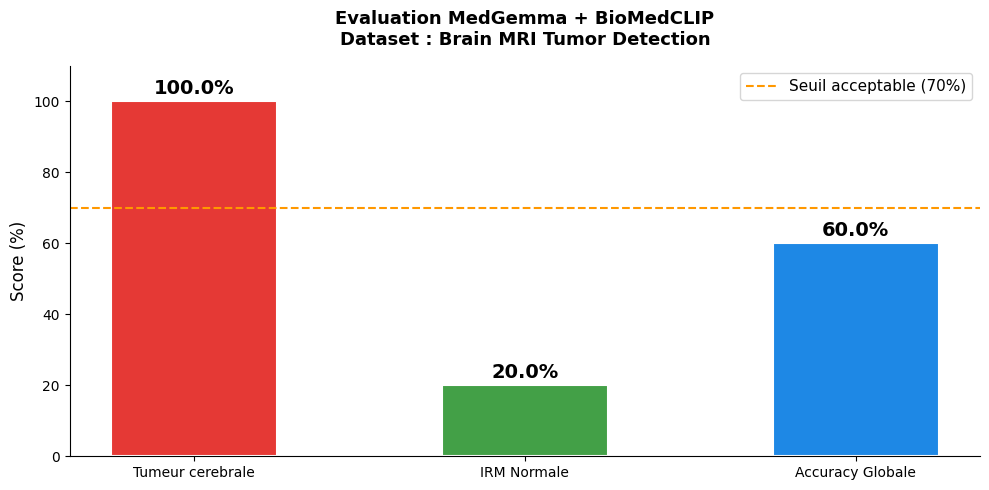

Graphique sauvegarde : evaluation_medgemma.png


In [15]:
# ================================================================
# KAGGLE D — GRAPHIQUE DES RESULTATS
# ================================================================

import matplotlib.pyplot as plt

categories = ["Tumeur cerebrale", "IRM Normale", "Accuracy Globale"]
scores     = [
    c_t     / len(res_tumeur) * 100,
    c_n     / len(res_normal) * 100,
    correct / total           * 100,
]
couleurs = ["#e53935", "#43a047", "#1e88e5"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, scores, color=couleurs,
              width=0.5, edgecolor="white", linewidth=1.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{score:.1f}%",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold")

ax.axhline(y=70, color="#ff9800", linestyle="--",
           linewidth=1.5, label="Seuil acceptable (70%)")
ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title(
    "Evaluation MedGemma + BioMedCLIP\nDataset : Brain MRI Tumor Detection",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("evaluation_medgemma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde : evaluation_medgemma.png")


In [16]:
# ================================================================
# EVAL-A — CONFIGURATION KAGGLE
# ================================================================
import os
from google.colab import userdata

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
chemin_cfg = os.path.expanduser("~/.kaggle/kaggle.json")
with open(chemin_cfg, "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
os.chmod(chemin_cfg, 0o600)

!pip install kaggle -q

# Vérifie que ça marche
result = !kaggle datasets list --search "chest xray" 2>&1
print(result[0] if result else "Kaggle OK")
print("EVAL-A OK ✅")

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
EVAL-A OK ✅


In [17]:
# ================================================================
# EVAL-B — TELECHARGEMENT DATASET OpenI (Chest X-ray Indiana)
# ================================================================
# Taille : ~1 Go — durée : 2-3 min

import os

!kaggle datasets download raddar/chest-xrays-indiana-university \
    --unzip -p ./data/openi/ -q

# Vérifie la structure
print("Contenu téléchargé :")
for item in sorted(os.listdir("./data/openi/")):
    print(f"  {item}")

# Vérifie les fichiers CSV
import pandas as pd

df_rapports = pd.read_csv("./data/openi/indiana_reports.csv")
df_proj     = pd.read_csv("./data/openi/indiana_projections.csv")

print(f"\nRapports   : {len(df_rapports)} lignes")
print(f"Projections: {len(df_proj)} lignes")
print(f"\nColonnes rapports : {list(df_rapports.columns)}")
print(f"Colonnes proj.    : {list(df_proj.columns)}")
print(f"\nExemple rapport :")
print(df_rapports[["uid","findings","impression"]].head(2).to_string())
print("\nEVAL-B OK ✅")

Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
Contenu téléchargé :
  images
  indiana_projections.csv
  indiana_reports.csv

Rapports   : 3851 lignes
Projections: 7466 lignes

Colonnes rapports : ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']
Colonnes proj.    : ['uid', 'filename', 'projection']

Exemple rapport :
   uid                                                                                                                                                                                                            findings                    impression
0    1  The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.          Normal chest x-XXXX.
1    2           

In [18]:
# ================================================================
# EVAL-C — PREPARATION DES DONNEES
# ================================================================

import os, pandas as pd
from PIL import Image

def preparer_dataset(dossier="./data/openi/", nb_cas=30, graine=42):
    """
    Charge les paires (image, rapport_réel) du dataset OpenI.
    Retourne un DataFrame prêt pour l'évaluation.
    """
    df_rapports = pd.read_csv(
        os.path.join(dossier, "indiana_reports.csv")
    )
    df_proj = pd.read_csv(
        os.path.join(dossier, "indiana_projections.csv")
    )

    # Garder uniquement les vues frontales (PA = Frontal)
    df_proj = df_proj[
        df_proj["projection"].str.contains("Frontal", case=False, na=False)
    ].copy()

    # Fusion rapports + images
    df = pd.merge(
        df_rapports,
        df_proj[["uid", "filename"]],
        on="uid"
    )

    # Nettoyage
    df = df.dropna(subset=["findings", "filename"])
    df["findings"]   = df["findings"].fillna("").astype(str).str.strip()
    df["impression"] = df["impression"].fillna("").astype(str).str.strip()

    # Trouver le dossier images
    for sous_dossier in ["images/images_normalized", "images", "."]:
        chemin_test = os.path.join(dossier, sous_dossier)
        if os.path.isdir(chemin_test):
            # Vérifie qu'il y a des images dedans
            imgs = [f for f in os.listdir(chemin_test)
                    if f.lower().endswith(('.png','.jpg','.jpeg'))]
            if imgs:
                dossier_imgs = chemin_test
                print(f"Images trouvées dans : {dossier_imgs}")
                break
    else:
        raise FileNotFoundError("Dossier images introuvable")

    # Vérifie que l'image existe sur le disque
    def image_existe(nom):
        return os.path.exists(os.path.join(dossier_imgs, nom))

    df = df[df["filename"].apply(image_existe)].copy()
    print(f"Cas avec image disponible : {len(df)}")

    # Échantillon aléatoire reproductible
    df_sample = df.sample(
        n=min(nb_cas, len(df)),
        random_state=graine
    ).reset_index(drop=True)

    print(f"Échantillon sélectionné   : {len(df_sample)} cas")
    return df_sample, dossier_imgs


# Lance la préparation
df_eval, DOSSIER_IMAGES = preparer_dataset(nb_cas=30, graine=42)

print("\nAperçu de l'échantillon :")
print(df_eval[["uid","filename","findings"]].head(3).to_string())
print("\nEVAL-C OK ✅")

Images trouvées dans : ./data/openi/images/images_normalized
Cas avec image disponible : 3307
Échantillon sélectionné   : 30 cas

Aperçu de l'échantillon :
    uid                   filename                                                                                                                                                                                                                                                                                                                                                                               findings
0    60    60_IM-2192-1001.dcm.png  Stable appearance of hiatal hernia. Clear right lung XXXX.In the left superior lower lobe there is a 1.9 x 1.8 cm round area of density which has increased in size compared to prior chest radiograph and recommend a XXXX chest, abdomen and pelvis with contrast as this area is suspicious for potential malignancy. Normal cardiac contour. No pneumothorax or pleural effusion.
1   794   794_IM-2331-10

In [19]:
# ================================================================
# EVAL-D — FONCTIONS DE COMPARAISON
# ================================================================

import re

# Mots-clés médicaux radiologiques importants
MOTS_CLES_MEDICAUX = [
    "cardiomegaly", "enlarged", "effusion", "pleural",
    "pneumonia", "consolidation", "atelectasis", "opacity",
    "pneumothorax", "edema", "infiltrate", "nodule",
    "mass", "fracture", "normal", "clear", "unremarkable",
    "bilateral", "costophrenic", "mediastinum", "heart",
    "lung", "airspace", "interstitial", "vascular"
]

def tokeniser(texte):
    """Extrait les mots de 3+ lettres en minuscules."""
    return set(re.findall(r'\b[a-zA-Z]{3,}\b', texte.lower()))

def calculer_f1(texte_ref, texte_gen):
    """F1 sur le chevauchement de mots."""
    ref = tokeniser(texte_ref)
    gen = tokeniser(texte_gen)
    if not ref or not gen:
        return 0.0, 0.0, 0.0
    communs   = ref & gen
    precision = len(communs) / len(gen)
    rappel    = len(communs) / len(ref)
    f1        = (2 * precision * rappel / (precision + rappel)
                 if (precision + rappel) > 0 else 0.0)
    return round(precision,3), round(rappel,3), round(f1,3)

def score_medical(texte_ref, texte_gen):
    """
    Taux de mots-clés médicaux du rapport réel
    retrouvés dans le rapport généré.
    """
    ref_l = texte_ref.lower()
    gen_l = texte_gen.lower()
    presents  = [m for m in MOTS_CLES_MEDICAUX if m in ref_l]
    if not presents:
        return 1.0, []
    retrouves = [m for m in presents if m in gen_l]
    manquants = [m for m in presents if m not in gen_l]
    return round(len(retrouves)/len(presents), 3), manquants

def verdict(f1, score_med):
    """Verdict qualitatif basé sur les deux scores."""
    if f1 >= 0.40 and score_med >= 0.70:
        return "Excellent"
    elif f1 >= 0.25 and score_med >= 0.50:
        return "Bon"
    elif f1 >= 0.15 and score_med >= 0.30:
        return "Acceptable"
    else:
        return "A ameliorer"

print("EVAL-D OK ✅ — Fonctions de comparaison prêtes")

EVAL-D OK ✅ — Fonctions de comparaison prêtes


In [20]:
# ================================================================
# EVAL-E — EVALUATION COMPLETE (autonome — tout inclus)
# ================================================================

import re, os, pandas as pd
from PIL import Image
from datetime import datetime

# ── Fonctions incluses directement ───────────────────────────
PREFIXES = [
    r"^Absolument\s*[!,.]?\s*",
    r"^Bien s.r\s*[!,.]?\s*",
    r"^Voici\s+.{0,120}[,:\n]",
    r"^Je vais\s+.{0,120}\.\s*",
    r"^Certainly\s*[!,.]?\s*",
    r"^D.accord\s*[!,.]?\s*",
    r"^En tant que radiologue\s*.{0,120}[,:\n]",
    r"^Bases? sur .{0,120}[,:\n]",
]

def nettoyer(texte):
    t = texte.strip()
    for p in PREFIXES:
        t = re.sub(p, "", t, flags=re.IGNORECASE|re.DOTALL).lstrip()
    while t.startswith("\n"):
        t = t[1:]
    return t.strip()

MOTS_CLES = [
    "cardiomegaly","enlarged","effusion","pleural",
    "pneumonia","consolidation","atelectasis","opacity",
    "pneumothorax","edema","infiltrate","nodule","mass",
    "fracture","normal","clear","unremarkable","bilateral",
    "costophrenic","mediastinum","heart","lung","airspace",
]

def tokeniser(texte):
    return set(re.findall(r'\b[a-zA-Z]{3,}\b', texte.lower()))

def calculer_f1(ref, gen):
    r, g = tokeniser(ref), tokeniser(gen)
    if not r or not g:
        return 0.0, 0.0, 0.0
    tp   = len(r & g)
    prec = tp / len(g)
    rec  = tp / len(r)
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    return round(prec,3), round(rec,3), round(f1,3)

def score_medical(ref, gen):
    rl, gl    = ref.lower(), gen.lower()
    presents  = [m for m in MOTS_CLES if m in rl]
    if not presents:
        return 1.0, []
    manquants = [m for m in presents if m not in gl]
    return round(1 - len(manquants)/len(presents), 3), manquants

def verdict(f1, sm):
    if f1 >= 0.40 and sm >= 0.70: return "Excellent"
    if f1 >= 0.25 and sm >= 0.50: return "Bon"
    if f1 >= 0.15 and sm >= 0.30: return "Acceptable"
    return "A ameliorer"

# ── Vérification des dépendances critiques ────────────────────
ok = True
for fn in ["detecter_avec_biomedclip", "generer_rapport_medgemma",
           "df_eval", "DOSSIER_IMAGES"]:
    if fn not in globals():
        print(f"MANQUANT : {fn}")
        ok = False
if not ok:
    raise RuntimeError(
        "Relance d'abord : Bloc2 → Bloc4 → Bloc5 → Bloc6 → Bloc7 → EVAL-C"
    )
print("Dependances OK")

# ── Evaluation ────────────────────────────────────────────────
NB_CAS = 20

print("="*60)
print(f"DEBUT — {NB_CAS} cas | {datetime.now().strftime('%H:%M:%S')}")
print("="*60)

resultats = []
erreurs   = 0

for i, (_, row) in enumerate(df_eval.head(NB_CAS).iterrows()):
    print(f"\n[{i+1}/{NB_CAS}] UID={row['uid']} — {row['filename']}")
    chemin = os.path.join(DOSSIER_IMAGES, row["filename"])
    try:
        img = Image.open(chemin).convert("RGB")
        img.thumbnail((512, 512), Image.LANCZOS)

        ref = (row["findings"].strip()
               + " " + row["impression"].strip()).strip()

        det  = detecter_avec_biomedclip(img)
        gen  = generer_rapport_medgemma(
            img, det,
            prompt_custom=(
                "Generate a radiology report with findings "
                "and impression for this chest X-ray."
            )
        )
        gen  = nettoyer(gen)

        prec, rec, f1 = calculer_f1(ref, gen)
        sm, manq      = score_medical(ref, gen)
        verd          = verdict(f1, sm)

        print(f"  F1={f1:.3f} | Med={sm:.0%} | {verd}")
        if manq:
            print(f"  Manquants: {', '.join(manq[:4])}")

        resultats.append({
            "uid"           : row["uid"],
            "image"         : row["filename"],
            "rapport_ref"   : ref[:500],
            "rapport_gen"   : gen[:500],
            "precision"     : prec,
            "recall"        : rec,
            "f1"            : f1,
            "score_medical" : sm,
            "mots_manquants": ", ".join(manq[:5]),
            "verdict"       : verd,
        })

    except Exception as e:
        print(f"  ERREUR : {e}")
        erreurs += 1

# ── Résumé ────────────────────────────────────────────────────
if not resultats:
    print("\nAucun résultat obtenu.")
    print(f"Erreurs : {erreurs}/{NB_CAS}")
else:
    df_res = pd.DataFrame(resultats)
    print("\n" + "="*60)
    print("RESULTATS")
    print("="*60)
    print(f"  Cas evalues   : {len(df_res)}/{NB_CAS}")
    print(f"  Erreurs       : {erreurs}")
    print(f"  F1 moyen      : {df_res['f1'].mean():.3f}")
    print(f"  Precision     : {df_res['precision'].mean():.3f}")
    print(f"  Rappel        : {df_res['recall'].mean():.3f}")
    print(f"  Score medical : {df_res['score_medical'].mean():.1%}")
    print()
    for v in ["Excellent","Bon","Acceptable","A ameliorer"]:
        n = (df_res["verdict"] == v).sum()
        print(f"  {v:<15} : {n:2d} cas  {'|'*n}")
    print("="*60)
    best  = df_res.loc[df_res["f1"].idxmax()]
    worst = df_res.loc[df_res["f1"].idxmin()]
    print(f"  Meilleur : UID {best['uid']} F1={best['f1']:.3f}")
    print(f"  Pire     : UID {worst['uid']} F1={worst['f1']:.3f}")

    nom = f"eval_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
    df_res.to_csv(nom, index=False)
    print(f"\n  CSV: {nom}")
    print("EVAL-E OK")

Dependances OK
DEBUT — 20 cas | 13:06:42

[1/20] UID=60 — 60_IM-2192-1001.dcm.png
[CLIP] Normal (0 findings retenus)
  F1=0.012 | Med=14% | A ameliorer
  Manquants: effusion, pleural, pneumothorax, mass

[2/20] UID=794 — 794_IM-2331-1001.dcm.png
[CLIP] Anomalies detectees (1 findings retenus)
  45.3% — pneumothorax
  F1=0.019 | Med=29% | A ameliorer
  Manquants: effusion, pleural, clear, heart

[3/20] UID=1138 — 1138_IM-0094-1001.dcm.png
[CLIP] Anomalies detectees (1 findings retenus)
  36.3% — atelectasis
  F1=0.018 | Med=17% | A ameliorer
  Manquants: effusion, pleural, consolidation, pneumothorax

[4/20] UID=1478 — 1478_IM-0310-0001-0002.dcm.png
[CLIP] Anomalies detectees (1 findings retenus)
  35.6% — pneumothorax
  F1=0.032 | Med=43% | A ameliorer
  Manquants: effusion, consolidation, edema, heart

[5/20] UID=244 — 244_IM-0978-1001.dcm.png
[CLIP] Anomalies detectees (1 findings retenus)
  35.7% — pneumothorax
  F1=0.000 | Med=0% | A ameliorer
  Manquants: unremarkable, mediastinum

TOP 3 — Meilleurs cas

UID : 2793  |  F1=0.135  |  Médical=57%  |  A ameliorer

──────────────────────────── RAPPORT REEL ────────────────────────────
The cardiomediastinal silhouette is normal in size and contour. Hyperexpanded lungs without focal consolidation, pneumothorax or large pleural effusion. Normal XXXX. Mild lung hyperexpansion, otherwise clear.

──────────────────────────── RAPPORT IA   ────────────────────────────
en tenant compte du contexte et des indices détectés automatiquement :

**Rapport d'Imagerie Médicale - Radiologie**

**Patient:** [Insérer le nom du patient]
**Date:** 2023-10-27
**Type d'examen:** Radiographie thoracique standard (PA)
**Indice détecté automatiquement:** Pneumothorax

**Observations:**

*   **Poumons:** Les poumons apparaissent gl

Mots manquants : effusion, clear, lung

UID : 1797  |  F1=0.055  |  Médical=60%  |  A ameliorer

──────────────────────────── RAPPORT REEL ────────────────────────────
The cardiomediastinal silhouette and pulmonary v

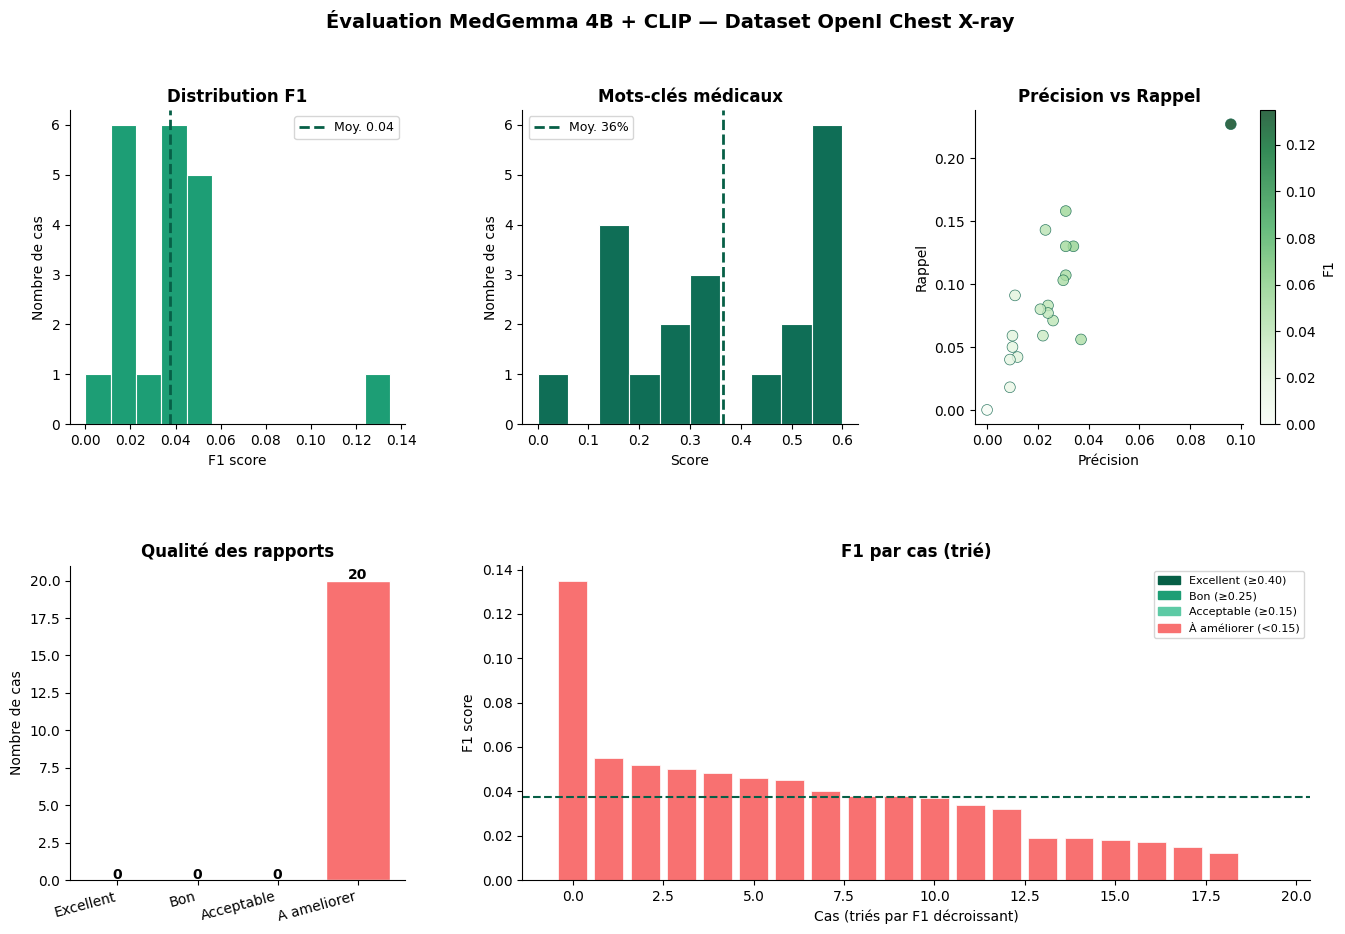

Graphiques sauvegardés : eval_graphiques.png
EVAL-F OK ✅


In [21]:
# ================================================================
# EVAL-F — COMPARAISON VISUELLE ET GRAPHIQUES
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Affiche les 3 meilleurs cas côte à côte ────────────────
print("TOP 3 — Meilleurs cas\n" + "="*60)
for _, row in df_res.nlargest(3, "f1").iterrows():
    print(f"\nUID : {row['uid']}  |  F1={row['f1']:.3f}"
          f"  |  Médical={row['score_medical']:.0%}"
          f"  |  {row['verdict']}")
    print(f"\n{'─'*28} RAPPORT REEL {'─'*28}")
    print(row["rapport_ref"][:350])
    print(f"\n{'─'*28} RAPPORT IA   {'─'*28}")
    print(row["rapport_gen"][:350])
    if row["mots_manquants"]:
        print(f"\nMots manquants : {row['mots_manquants']}")
    print("="*60)

# ── 2. Affiche le pire cas ────────────────────────────────────
print("\nPIRE CAS\n" + "="*60)
row = df_res.loc[df_res["f1"].idxmin()]
print(f"UID : {row['uid']}  |  F1={row['f1']:.3f}")
print(f"\nRAPPORT REEL :\n{row['rapport_ref'][:300]}")
print(f"\nRAPPORT IA   :\n{row['rapport_gen'][:300]}")
print("="*60)

# ── 3. Graphiques ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "Évaluation MedGemma 4B + CLIP — Dataset OpenI Chest X-ray",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

VERT  = "#1D9E75"
VERT2 = "#065f46"
GRIS  = "#F2F8F6"

# Distribution F1
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_res["f1"], bins=12, color=VERT, edgecolor="white", linewidth=0.8)
ax1.axvline(df_res["f1"].mean(), color=VERT2, linestyle="--",
            linewidth=2, label=f"Moy. {df_res['f1'].mean():.2f}")
ax1.set_title("Distribution F1", fontweight="bold")
ax1.set_xlabel("F1 score")
ax1.set_ylabel("Nombre de cas")
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Score médical
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_res["score_medical"], bins=10,
         color="#0F6E56", edgecolor="white", linewidth=0.8)
ax2.axvline(df_res["score_medical"].mean(),
            color=VERT2, linestyle="--", linewidth=2,
            label=f"Moy. {df_res['score_medical'].mean():.0%}")
ax2.set_title("Mots-clés médicaux", fontweight="bold")
ax2.set_xlabel("Score")
ax2.set_ylabel("Nombre de cas")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# Précision vs Rappel
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(
    df_res["precision"], df_res["recall"],
    c=df_res["f1"], cmap="Greens",
    alpha=0.8, s=60, edgecolors="#065f46", linewidths=0.5
)
plt.colorbar(scatter, ax=ax3, label="F1")
ax3.set_title("Précision vs Rappel", fontweight="bold")
ax3.set_xlabel("Précision")
ax3.set_ylabel("Rappel")
ax3.spines[["top","right"]].set_visible(False)

# Verdicts (bar chart)
ax4 = fig.add_subplot(gs[1, 0])
verdicts  = ["Excellent","Bon","Acceptable","A ameliorer"]
couleurs  = ["#065f46","#1D9E75","#5DCAA5","#F87171"]
comptages = [
    (df_res["verdict"] == v).sum()
    for v in verdicts
]
bars = ax4.bar(verdicts, comptages, color=couleurs, edgecolor="white")
for bar, val in zip(bars, comptages):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             str(val), ha="center", fontweight="bold", fontsize=10)
ax4.set_title("Qualité des rapports", fontweight="bold")
ax4.set_ylabel("Nombre de cas")
ax4.spines[["top","right"]].set_visible(False)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=15, ha="right")

# F1 par cas (ordonné)
ax5 = fig.add_subplot(gs[1, 1:])
df_sorted = df_res.sort_values("f1", ascending=False).reset_index(drop=True)
couleurs_bar = [
    "#065f46" if v == "Excellent" else
    "#1D9E75" if v == "Bon" else
    "#5DCAA5" if v == "Acceptable" else
    "#F87171"
    for v in df_sorted["verdict"]
]
ax5.bar(range(len(df_sorted)), df_sorted["f1"],
        color=couleurs_bar, edgecolor="white", linewidth=0.5)
ax5.axhline(df_sorted["f1"].mean(), color=VERT2,
            linestyle="--", linewidth=1.5,
            label=f"Moyenne F1 = {df_sorted['f1'].mean():.2f}")
ax5.set_title("F1 par cas (trié)", fontweight="bold")
ax5.set_xlabel("Cas (triés par F1 décroissant)")
ax5.set_ylabel("F1 score")
ax5.legend(fontsize=9)
ax5.spines[["top","right"]].set_visible(False)

# Légende couleurs
from matplotlib.patches import Patch
legende = [
    Patch(color="#065f46", label="Excellent (≥0.40)"),
    Patch(color="#1D9E75", label="Bon (≥0.25)"),
    Patch(color="#5DCAA5", label="Acceptable (≥0.15)"),
    Patch(color="#F87171", label="À améliorer (<0.15)"),
]
ax5.legend(handles=legende, loc="upper right", fontsize=8)

plt.savefig("eval_graphiques.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Graphiques sauvegardés : eval_graphiques.png")
print("EVAL-F OK ✅")

In [22]:
# ================================================================
# PREP-A — TELECHARGER OPENI ET CREER LE ZIP POUR LE TEST
# ================================================================

import os, zipfile, shutil, pandas as pd
from google.colab import userdata

# ── Configuration Kaggle ───────────────────────────────────────
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!pip install kaggle -q

# ── Téléchargement OpenI ───────────────────────────────────────
print("Téléchargement OpenI...")
!kaggle datasets download raddar/chest-xrays-indiana-university \
    --unzip -p ./data/openi/ -q
print("Téléchargement terminé ✅")

# ── Vérifie la structure ───────────────────────────────────────
print("\nContenu ./data/openi/ :")
for item in sorted(os.listdir("./data/openi/")):
    print(f"  {item}")

Téléchargement OpenI...
Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
Téléchargement terminé ✅

Contenu ./data/openi/ :
  images
  indiana_projections.csv
  indiana_reports.csv


In [23]:
# ================================================================
# PREP-B — CREER UN DOSSIER PATIENT TEST ET SON ZIP
# ================================================================
# Cette cellule :
# 1. Sélectionne N images d'un même patient (même region anatomique)
# 2. Copie dans un dossier structuré
# 3. Crée le ZIP prêt à uploader dans Gradio

import os, shutil, zipfile, pandas as pd
from PIL import Image

NB_IMAGES_TEST = 10   # ← modifie selon ton test (10 à 100)

# ── Charge le dataset ─────────────────────────────────────────
df_rapports = pd.read_csv("./data/openi/indiana_reports.csv")
df_proj     = pd.read_csv("./data/openi/indiana_projections.csv")

# Vues frontales uniquement
df_proj = df_proj[
    df_proj["projection"].str.contains("Frontal", case=False, na=False)
].copy()

df = pd.merge(df_rapports, df_proj[["uid","filename"]], on="uid")
df = df.dropna(subset=["findings", "filename"])

# Trouver le dossier images
for sous in ["images/images_normalized", "images", "."]:
    d = os.path.join("./data/openi/", sous)
    if os.path.isdir(d):
        imgs_dispo = [f for f in os.listdir(d)
                      if f.lower().endswith('.png')]
        if imgs_dispo:
            DOSSIER_IMGS = d
            break

print(f"Dossier images : {DOSSIER_IMGS}")
print(f"Images disponibles : {len(imgs_dispo)}")

# ── Filtre les images qui existent vraiment sur disque ─────────
df["chemin"] = df["filename"].apply(
    lambda f: os.path.join(DOSSIER_IMGS, f)
)
df = df[df["chemin"].apply(os.path.exists)].copy()
print(f"Images confirmées sur disque : {len(df)}")

# ── Sélection aléatoire reproductible ─────────────────────────
df_test = df.sample(
    n=min(NB_IMAGES_TEST, len(df)),
    random_state=42
).reset_index(drop=True)

print(f"Images sélectionnées : {len(df_test)}")

# ── Création du dossier patient ───────────────────────────────
NOM_PATIENT   = "Patient_Test_OpenI"
DOSSIER_DEST  = f"./dossier_{NOM_PATIENT}"
CHEMIN_ZIP    = f"./{NOM_PATIENT}.zip"

# Nettoie si déjà existant
if os.path.exists(DOSSIER_DEST):
    shutil.rmtree(DOSSIER_DEST)
os.makedirs(DOSSIER_DEST, exist_ok=True)

# ── Copie les images ──────────────────────────────────────────
copiees = 0
for _, row in df_test.iterrows():
    src = row["chemin"]
    dst = os.path.join(DOSSIER_DEST, row["filename"])
    try:
        shutil.copy2(src, dst)
        copiees += 1
    except Exception as e:
        print(f"Erreur copie {row['filename']} : {e}")

print(f"Images copiées : {copiees}/{len(df_test)}")

# ── Sauvegarde les rapports de référence (pour comparaison) ───
rapport_ref_path = os.path.join(DOSSIER_DEST, "_rapports_reference.csv")
df_test[["uid","filename","findings","impression"]].to_csv(
    rapport_ref_path, index=False
)
print(f"Rapports référence : {rapport_ref_path}")

# ── Création du ZIP ───────────────────────────────────────────
if os.path.exists(CHEMIN_ZIP):
    os.remove(CHEMIN_ZIP)

with zipfile.ZipFile(CHEMIN_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fichier in os.listdir(DOSSIER_DEST):
        chemin_f = os.path.join(DOSSIER_DEST, fichier)
        zf.write(chemin_f, fichier)

taille_mb = os.path.getsize(CHEMIN_ZIP) / 1e6
print(f"\nZIP créé : {CHEMIN_ZIP}")
print(f"Taille   : {taille_mb:.1f} Mo")
print(f"Images   : {copiees}")

# ── Affiche le résumé ─────────────────────────────────────────
print("\n" + "="*55)
print("RESUME DU DOSSIER PATIENT TEST")
print("="*55)
for _, row in df_test.iterrows():
    uid = row["uid"]
    fn  = row["filename"][:35]
    ref = row["findings"][:60] + "..."
    print(f"  UID {uid:<6} | {fn:<35} | {ref}")
print("="*55)
print("\nPREP-B OK ✅")

Dossier images : ./data/openi/images/images_normalized
Images disponibles : 7470
Images confirmées sur disque : 3307
Images sélectionnées : 10
Images copiées : 10/10
Rapports référence : ./dossier_Patient_Test_OpenI/_rapports_reference.csv

ZIP créé : ./Patient_Test_OpenI.zip
Taille   : 20.8 Mo
Images   : 10

RESUME DU DOSSIER PATIENT TEST
  UID 60     | 60_IM-2192-1001.dcm.png             | Stable appearance of hiatal hernia. Clear right lung XXXX.In...
  UID 794    | 794_IM-2331-1001.dcm.png            | Normal heart size and mediastinal contours. Lungs are clear....
  UID 1138   | 1138_IM-0094-1001.dcm.png           | No pleural effusions. No pneumothorax. No focal areas of con...
  UID 1478   | 1478_IM-0310-0001-0002.dcm.png      | Stable cardiomediastinal silhouette with normal heart size, ...
  UID 244    | 244_IM-0978-1001.dcm.png            | Heart XXXX, mediastinum, XXXX, bony structures and lung XXXX...
  UID 2998   | 2998_IM-1382-1001.dcm.png           | The lungs are clear 

In [24]:
# ================================================================
# PREP-C — TELECHARGER LE ZIP SUR TON ORDINATEUR
# ================================================================

from google.colab import files

print(f"Téléchargement du ZIP : {CHEMIN_ZIP}")
files.download(CHEMIN_ZIP)
print("Le ZIP est dans tes téléchargements ✅")
print(f"\nFichier : {NOM_PATIENT}.zip")
print("→ Va sur l'interface Gradio")
print("→ Onglet 'Dossier complet (ZIP)'")
print("→ Uploade ce fichier ZIP")
print("→ Remplis Nom patient et Région anatomique")
print("→ Clique 'Lancer l'analyse'")

Téléchargement du ZIP : ./Patient_Test_OpenI.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Le ZIP est dans tes téléchargements ✅

Fichier : Patient_Test_OpenI.zip
→ Va sur l'interface Gradio
→ Onglet 'Dossier complet (ZIP)'
→ Uploade ce fichier ZIP
→ Remplis Nom patient et Région anatomique
→ Clique 'Lancer l'analyse'


In [25]:
# ================================================================
# PREP-D — COMPARER LE RAPPORT GENERE PAR GRADIO
#          AVEC LES RAPPORTS DE REFERENCE OPENI
# ================================================================
# Exécute cette cellule APRES avoir téléchargé le rapport PDF
# de Gradio et récupéré le texte du rapport affiché

import re, pandas as pd

# ── Charge les rapports de référence ─────────────────────────
df_ref = pd.read_csv(
    os.path.join(DOSSIER_DEST, "_rapports_reference.csv")
)

print("RAPPORTS DE REFERENCE (OpenI) :")
print("="*60)
for _, row in df_ref.iterrows():
    print(f"\nUID {row['uid']} — {row['filename']}")
    print(f"FINDINGS   : {str(row['findings'])[:200]}")
    print(f"IMPRESSION : {str(row['impression'])[:150]}")
    print("─"*60)

# ── Résumé médical de référence ───────────────────────────────
tous_findings = " ".join(df_ref["findings"].fillna("").tolist()).lower()
tous_impression = " ".join(df_ref["impression"].fillna("").tolist()).lower()

MOTS = [
    "cardiomegaly","effusion","pneumonia","consolidation",
    "atelectasis","pneumothorax","edema","nodule","mass",
    "fracture","normal","clear","bilateral","pleural","opacity"
]

print("\nMOTS-CLES MEDICAUX DANS LES RAPPORTS REFERENCE :")
print("="*60)
for mot in MOTS:
    n_find = tous_findings.count(mot)
    n_imp  = tous_impression.count(mot)
    if n_find + n_imp > 0:
        print(f"  {mot:<20} : {n_find} findings | {n_imp} impressions")

print("\n" + "="*60)
print("UTILISATION :")
print("  1. Lance ton interface Gradio (Bloc 10)")
print("  2. Uploade le ZIP dans l'onglet 'Dossier complet'")
print(f"     Fichier : {CHEMIN_ZIP}")
print("  3. Remplis :")
print(f"     Nom patient    : {NOM_PATIENT}")
print("     Région         : Thorax (Chest X-ray)")
print("  4. Clique 'Lancer l'analyse'")
print("  5. Compare le rapport affiché avec les références ci-dessus")
print("="*60)
print("PREP-D OK ✅")

RAPPORTS DE REFERENCE (OpenI) :

UID 60 — 60_IM-2192-1001.dcm.png
FINDINGS   : Stable appearance of hiatal hernia. Clear right lung XXXX.In the left superior lower lobe there is a 1.9 x 1.8 cm round area of density which has increased in size compared to prior chest radiograph a
IMPRESSION : 1. Round area of density measuring 1.9 x 1.8 cm in left superior lower lobe with interval increased size compared to prior imaging. Recommend XXXX che
────────────────────────────────────────────────────────────

UID 794 — 794_IM-2331-1001.dcm.png
FINDINGS   : Normal heart size and mediastinal contours. Lungs are clear. There is no pneumothorax or pleural effusion. Postoperative changes seen in the left humerus. No acute bony abnormalities.
IMPRESSION : No acute cardiopulmonary process. .
────────────────────────────────────────────────────────────

UID 1138 — 1138_IM-0094-1001.dcm.png
FINDINGS   : No pleural effusions. No pneumothorax. No focal areas of consolidation. Heart size within normal limi